In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from imu.SensorUtils import SensorUtils

data = pd.read_csv('data/imu_noise_xyz.csv')
euler_gt = data[['euler_x', 'euler_y', 'euler_z']].values
ts = data['ts'].values/1000
ts -= ts[0]
acc = data[['accelerometer_x', 'accelerometer_y', 'accelerometer_z']].values
mag = data[['magnetometer_x', 'magnetometer_y', 'magnetometer_z']].values
gyro = data[['gyroscope_x', 'gyroscope_y', 'gyroscope_z']].values

acc_si = SensorUtils.cvt_acc_si(acc)
mag_si = SensorUtils.cvt_mag_si(mag)
gyro_si = SensorUtils.cvt_gyro_si(gyro)
N = len(ts)

def x_dot(omega, euler):
    phi, theta, psi = euler
    fx = np.array([[1, np.sin(phi)*np.tan(theta), np.cos(phi)*np.tan(theta)],
                   [0, np.cos(phi), -np.sin(phi)],
                   [0, np.sin(phi)/np.cos(theta), np.cos(phi)/np.cos(theta)]])
    return fx @ omega

def A_jacob(omega, euler):
    p, q, r = omega
    phi, theta, psi = euler
    A = np.zeros((3, 3))
    A[0, 0] = q*np.cos(phi)*np.tan(theta) - r*np.sin(phi)*np.tan(theta)
    A[0, 1] = np.cos(phi)/np.cos(theta)**2 + r*np.sin(phi)/np.cos(theta)**2
    A[1, 0] = -q*np.sin(phi) - r*np.cos(phi)
    A[2,0] = q*np.cos(phi)/np.cos(theta) - r*np.sin(phi)/np.cos(theta)
    A[2,1] = np.sin(phi)*np.tan(theta)/np.cos(theta) + r*np.cos(phi)*np.tan(theta)/np.cos(theta)
    return A

In [2]:

def get_euler_measurement(acc, mag):
    euler_xy_meas = SensorUtils.acc2eul(acc)
    euler_meas = SensorUtils.mag2eul(mag, euler_xy_meas)
    return euler_meas

In [3]:
Q = np.eye(3)*1e-2 # process noise
R = np.eye(3)*1e-1 # measurement noise accelerometer
H = np.eye(3) # measurement matrix
P = np.eye(3) # initial covariance
states = np.zeros((N, 3))

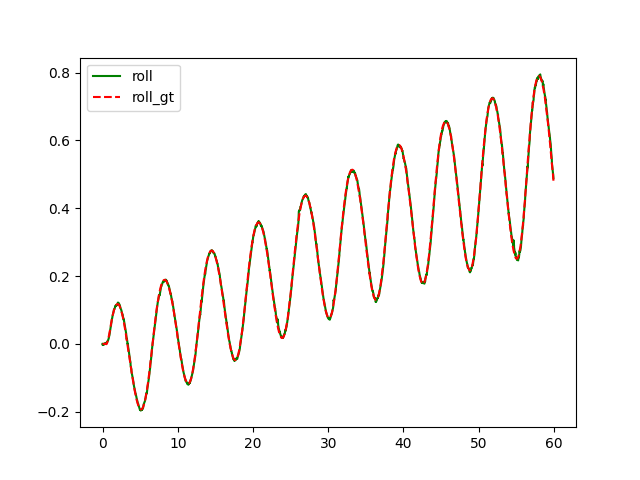

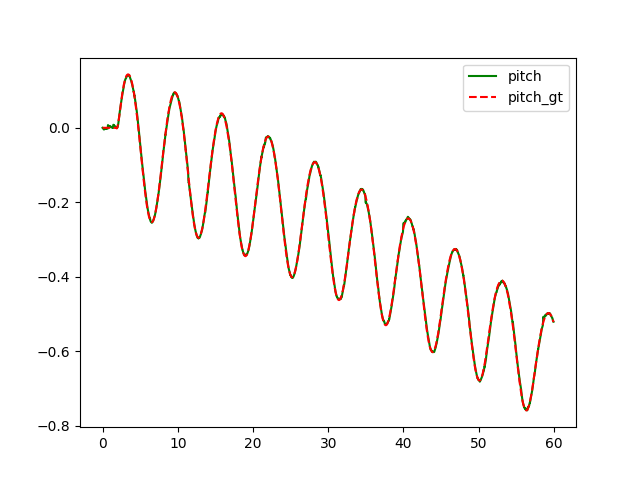

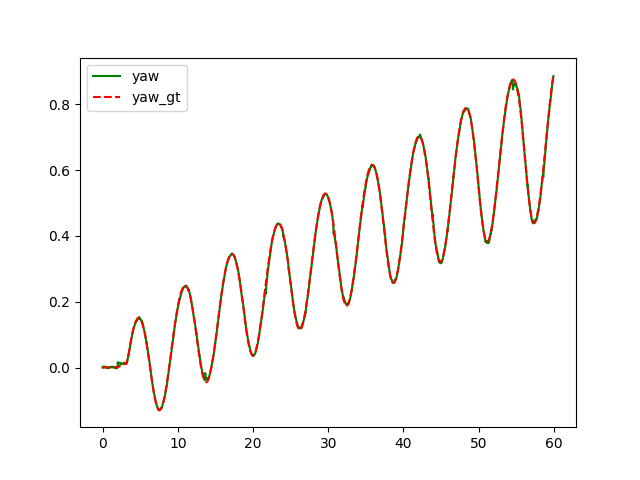

In [4]:
error_mag = np.zeros((N, 3))
for i in range(N-1):
    # time step
    dt = ts[i+1] - ts[i]

    # prediction of the next euler angles
    state_now = states[i]
    states_pred = state_now + x_dot(gyro_si[i], state_now) * dt
    # prediction of  the next covariance
    A = A_jacob(gyro_si[i], state_now)
    P_pred = A @ P @ A.T + Q

    # calculate kalman gain and error
    K = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R) # kalman gain
    z = get_euler_measurement(acc_si[i], mag_si[i]) # measurement
    error = z - H@states_pred
    error_mag[i] = error

    # correct
    states_corr = states_pred + K @ error
    P_corr = (np.eye(3) - K @ H) @ P_pred

    # update
    states[i+1] = states_corr
    P = P_corr

plt.figure()
plt.plot(ts, states[:,0], 'g', label='roll')
plt.plot(ts, euler_gt[:,0] * np.pi/180, 'r--', label='roll_gt')
plt.legend()

plt.figure()
plt.plot(ts, states[:,1], 'g', label='pitch')
plt.plot(ts, euler_gt[:,1] * np.pi/180, 'r--', label='pitch_gt')
plt.legend()

plt.figure()
plt.plot(ts, states[:,2], 'g', label='yaw')
plt.plot(ts, euler_gt[:,2] * np.pi/180, 'r--', label='yaw_gt')
plt.legend()

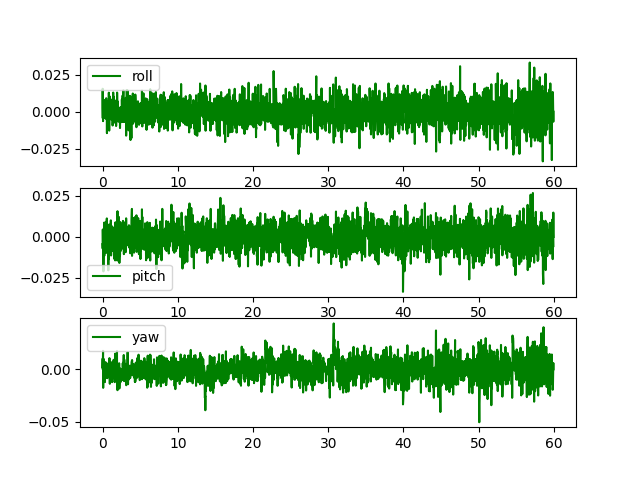

In [5]:
plt.figure()
plt.subplot(3,1,1)
plt.plot(ts, error_mag[:,0], 'g', label='roll')
plt.legend()

plt.subplot(3,1,2)
plt.plot(ts, error_mag[:,1], 'g', label='pitch')
plt.legend()

plt.subplot(3,1,3)
plt.plot(ts, error_mag[:,2], 'g', label='yaw')
plt.legend()